In [53]:
player_stats.to_json(
    "../Outputs/player_stats.json",
    orient="records"
)

In [ ]:
player_stats["Strike Rate"] = (
    player_stats["Runs"] /
    player_stats["Balls"]
) * 100

player_stats["Strike Rate"] = (
    player_stats["Strike Rate"]
    .round(2)
)

,Player,Runs,Balls,Fours,Sixes,Strike Rate
658,V Kohli,8671,6523,774.0,292.0,132.93


In [49]:
player_stats = player_runs.merge(
    player_balls,
    on="Player"
)

player_stats = player_stats.merge(
    fours,
    on="Player",
    how="left"
)

player_stats = player_stats.merge(
    sixes,
    on="Player",
    how="left"
)

player_stats.fillna(0, inplace=True)

In [48]:
player_runs = (
    df.groupby("batter")["runs_batter"]
      .sum()
      .reset_index()
)

player_runs.columns = ["Player", "Runs"]

fours = (
    df[df["runs_batter"] == 4]
    .groupby("batter")
    .size()
    .reset_index(name="Fours")
)

fours.rename(
    columns={"batter":"Player"},
    inplace=True
)

sixes = (
    df[df["runs_batter"] == 6]
    .groupby("batter")
    .size()
    .reset_index(name="Sixes")
)

sixes.rename(
    columns={"batter":"Player"},
    inplace=True
)

In [ ]:
player_balls = (
    df.groupby("batter")["balls_faced"]
      .sum()
      .reset_index()
)

player_balls.columns = ["Player", "Balls"]

player_balls.head()

In [42]:
top_runs.reset_index().to_json(
    "../Outputs/top_runs.json",
    orient="records"
)



top_wickets.reset_index().to_json(
    "../Outputs/top_wickets.json",
    orient="records"
)


team_wins.reset_index().to_json(
    "../Outputs/team_wins.json",
    orient="records"
)


venue_matches.reset_index().to_json(
    "../Outputs/venue_analysis.json",
    orient="records"
)


season_runs.reset_index().to_json(
    "../Outputs/season_analysis.json",
    orient="records"
)

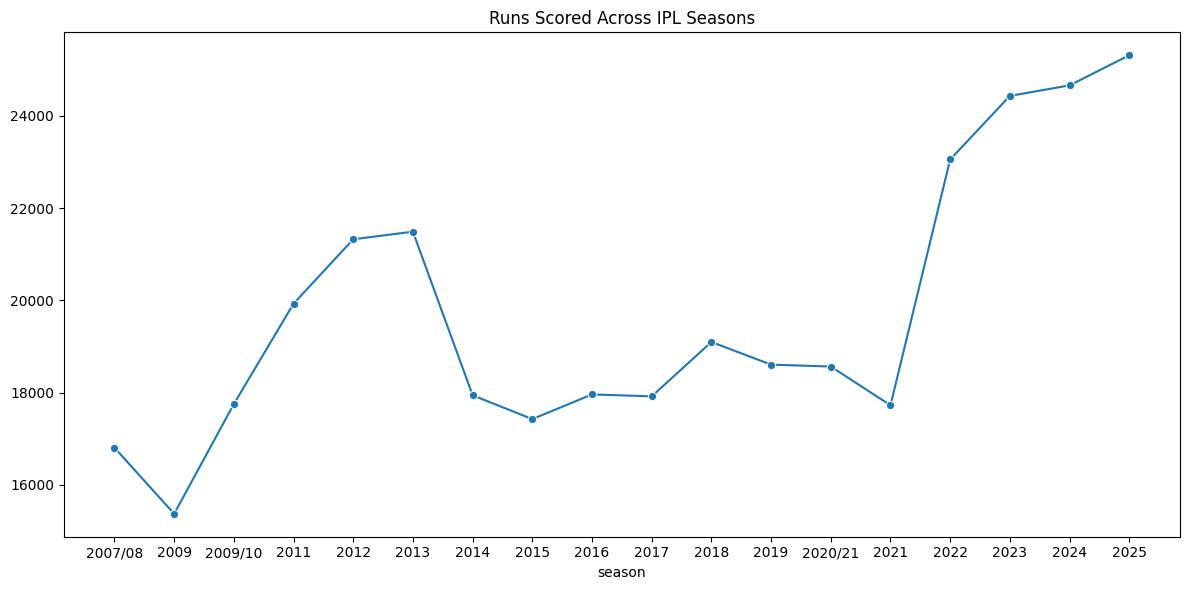

In [61]:
season_runs = (
    df.groupby("season")["runs_batter"]
      .sum()
)


plt.figure(figsize=(12,6))

sns.lineplot(
    x=season_runs.index,
    y=season_runs.values,
    marker="o"
)

plt.title("Runs Scored Across IPL Seasons")

plt.tight_layout()

plt.savefig("../Charts/season_runs.png")

plt.show()

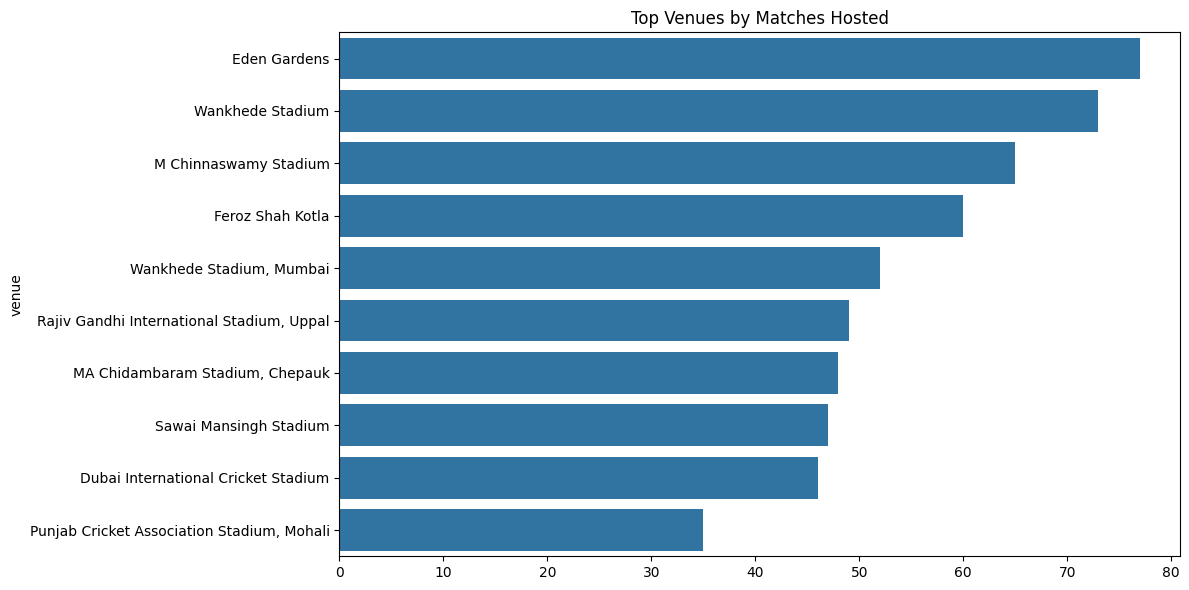

In [60]:
venue_matches = (
    df.groupby("venue")["match_id"]
      .nunique()
      .sort_values(ascending=False)
)

venue_matches.head(10)


plt.figure(figsize=(12,6))

sns.barplot(
    x=venue_matches.head(10).values,
    y=venue_matches.head(10).index
)

plt.title("Top Venues by Matches Hosted")

plt.tight_layout()

plt.savefig("../Charts/venue_matches.png")

plt.show()

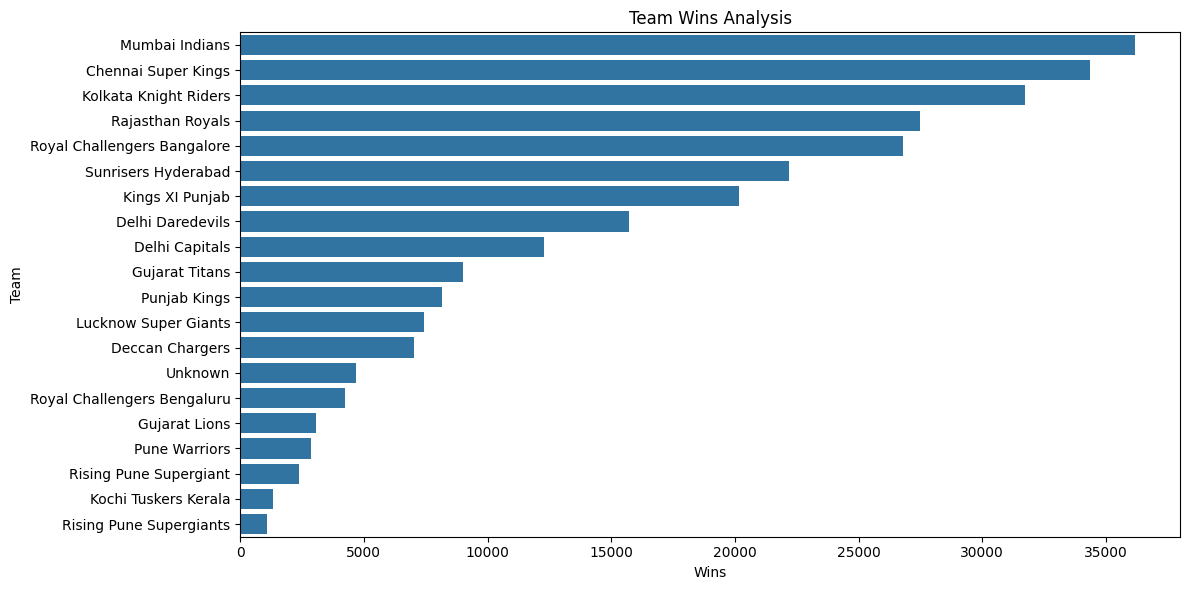

In [66]:
team_wins = (
    df["match_won_by"]
    .dropna()
    .value_counts()
)

team_wins


plt.figure(figsize=(12,6))

sns.barplot(
    x=team_wins.values,
    y=team_wins.index
)

plt.xlabel("Wins")
plt.ylabel("Team")

plt.title("Team Wins Analysis")

plt.tight_layout()

plt.savefig("../Charts/team_wins.png")

plt.show()

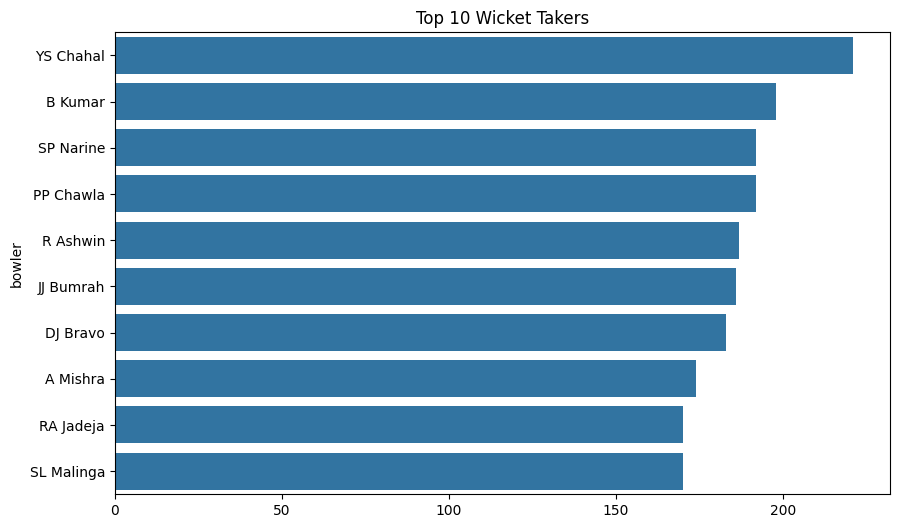

In [58]:
top_wickets = (
    df.groupby("bowler")["bowler_wicket"]
      .sum()
      .sort_values(ascending=False)
)

top_wickets.head(10)



plt.figure(figsize=(10,6))

sns.barplot(
    x=top_wickets.head(10).values,
    y=top_wickets.head(10).index
)

plt.title("Top 10 Wicket Takers")

plt.savefig("../Charts/top_wickets.png")


plt.show()

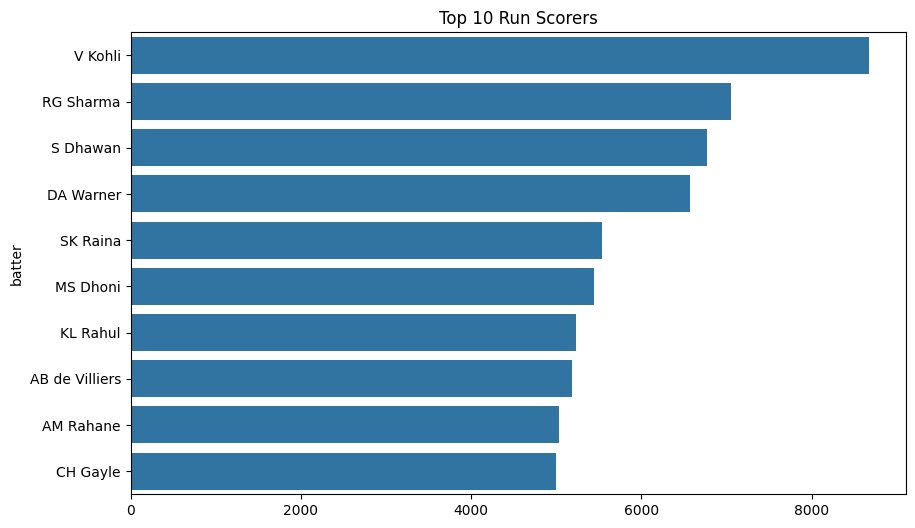

In [57]:
top_runs = (
    df.groupby("batter")["runs_batter"]
      .sum()
      .sort_values(ascending=False)
)

top_runs.head(10)


plt.figure(figsize=(10,6))

sns.barplot(
    x=top_runs.head(10).values,
    y=top_runs.head(10).index
)

plt.title("Top 10 Run Scorers")

plt.savefig("../Charts/top_runs.png")

plt.show()

In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.isnull().sum().sort_values(ascending=False).head(20)

df.dtypes

df["batting_team"].unique()

print(df["batter"].nunique())

Rows: 278205
Columns: 64
703


In [2]:
df = pd.read_csv(
    r"C:\Users\MVS SRI MANIJA REDDY\Desktop\IPL-Statistics-Dashboard\Data\IPL.csv",
    low_memory=False
)

df.head()

,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,ball_no,batter,bat_pos,runs_batter,balls_faced,bowler,valid_ball,runs_extras,runs_total,runs_bowler,runs_not_boundary,extra_type,non_striker,non_striker_pos,wicket_kind,player_out,fielders,runs_target,review_batter,team_reviewed,review_decision,umpire,umpires_call,player_of_match,match_won_by,win_outcome,toss_winner,toss_decision,venue,city,day,month,year,season,gender,team_type,superover_winner,result_type,method,balls_per_over,overs,event_match_no,stage,match_number,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,131970,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,0.1,SC Ganguly,1,0,1,P Kumar,1,1,1,0,False,legbyes,BB McCullum,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,BB McCullum,Kolkata Knight Riders,140 runs,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,18,4,2008,2007/08,male,club,NaN,NaN,NaN,6,20,1,Unknown,Unknown,1,1,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,131971,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,0.2,BB McCullum,2,0,1,P Kumar,1,0,0,0,False,NaN,SC Ganguly,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,BB McCullum,Kolkata Knight Riders,140 runs,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,18,4,2008,2007/08,male,club,NaN,NaN,NaN,6,20,1,Unknown,Unknown,1,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,131972,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,0.3,BB McCullum,2,0,0,P Kumar,0,1,1,1,False,wides,SC Ganguly,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,BB McCullum,Kolkata Knight Riders,140 runs,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,18,4,2008,2007/08,male,club,NaN,NaN,NaN,6,20,1,Unknown,Unknown,2,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,131973,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,0.3,BB McCullum,2,0,1,P Kumar,1,0,0,0,False,NaN,SC Ganguly,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,BB McCullum,Kolkata Knight Riders,140 runs,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,18,4,2008,2007/08,male,club,NaN,NaN,NaN,6,20,1,Unknown,Unknown,2,3,0,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,131974,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,0.4,BB McCullum,2,0,1,P Kumar,1,0,0,0,False,NaN,SC Ganguly,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,BB McCullum,Kolkata Knight Riders,140 runs,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,18,4,2008,2007/08,male,club,NaN,NaN,NaN,6,20,1,Unknown,Unknown,2,4,0,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)